<a href="https://colab.research.google.com/github/Mohammad-Salhi/mohammad/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:

df = df.dropna()

df = df[df['review'].str.len() > 20]

In [4]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [5]:
# طول النص
df['text_length'] = df['review'].apply(len)

# عدد الكلمات
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# عدد علامات التعجب
df['exclamation_count'] = df['review'].apply(lambda x: x.count('!'))

In [6]:

df = df[df['text_length'] < 2000]

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_text = vectorizer.fit_transform(df['clean_review'])

In [9]:
import numpy as np

extra_features = df[['text_length', 'word_count', 'exclamation_count']].values

from scipy.sparse import hstack

X = hstack([X_text, extra_features])
y = df['sentiment']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8783068783068783


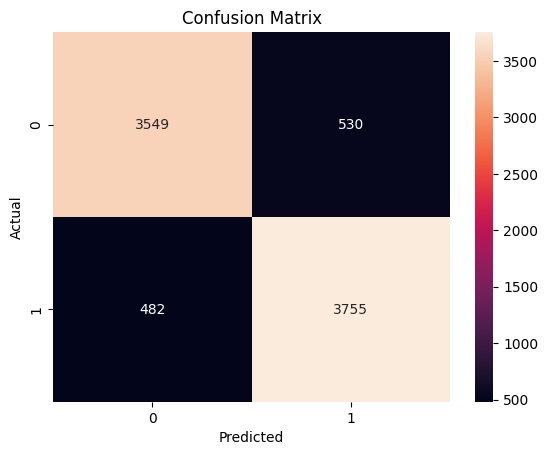

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

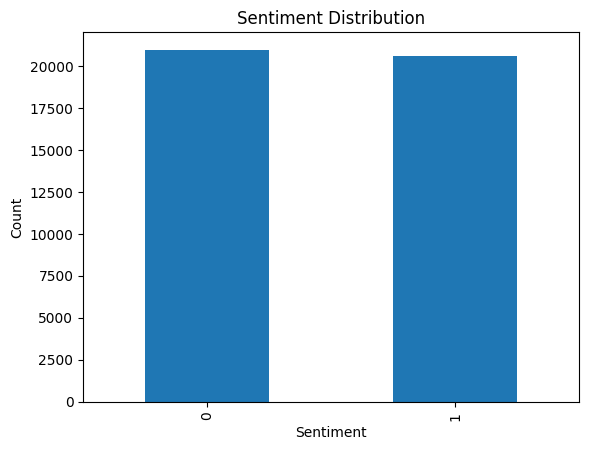

In [14]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

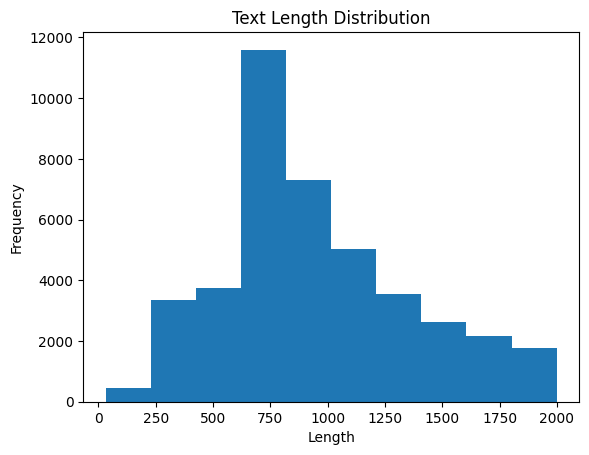

In [15]:
plt.hist(df['text_length'])
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

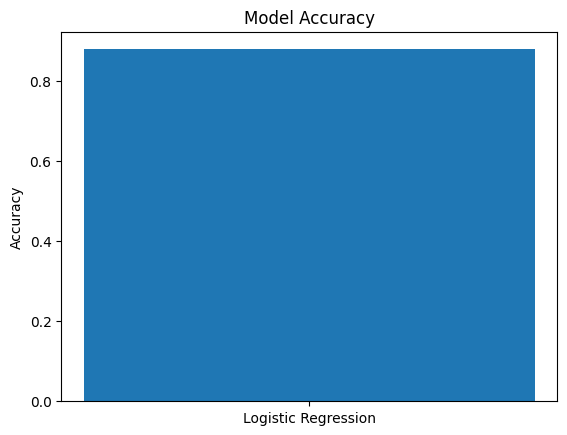

In [16]:
models = ['Logistic Regression']
accuracy = [accuracy_score(y_test, y_pred)]

plt.bar(models, accuracy)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

In [20]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def chatbot():
    print("🤖 Sentiment Analysis ChatBot")
    print("Type 'exit' to stop\n")

    while True:
        user_input = input("🧑 You: ")

        if user_input.lower() == 'exit':
            print("🤖 Bot: Goodbye 👋")
            break


        clean = clean_text(user_input)

        vec = vectorizer.transform([clean])

        pred = model.predict(vec)


        if pred[0] == 1:
            print("🤖 Bot: This review is Positive 😊\n")
        else:
            print("🤖 Bot: This review is Negative 😡\n")

In [ ]:
chatbot()

🤖 Sentiment Analysis ChatBot
Type 'exit' to stop

